---
date: "2026-07-19"
date-modified: last-modified
format:
  html:
    toc: true
---


# Conditional Expectation

## 1\. Two-Envelope Paradox & Conditioning on Events

When we observe or condition on the occurrence of an [event](event.ipynb) $A$, our expectations regarding a [random variable](random-variables.ipynb) $Y$ must be updated to reflect this new information. The **conditional expectation of $Y$ given an event $A$**, denoted $E(Y \mid A)$, is computed analogously to the unconditional [expected value](expectation.ipynb) $E(Y)$, but using [conditional probabilities](conditional-probability.ipynb) given that $A$ has occurred.

::: {#def-conditional-expectation-event}

## Conditional Expectation Given an Event

Let $A$ be an event with positive probability, $P(A) > 0$. If $Y$ is a discrete random variable with [probability mass function](probability-mass-function.ipynb) $P(Y = y)$, then the conditional expectation of $Y$ given $A$ is defined as:
$$ E(Y \mid A) = \sum_{y} y P(Y = y \mid A) $$
where the sum is taken over the support of $Y$. If $Y$ is a continuous random variable with [probability density function](probability-density-function.ipynb) $f_Y(y)$, then the conditional expectation given $A$ is:
$$ E(Y \mid A) = \int_{-\infty}^{\infty} y f_{Y \mid A}(y \mid A) \, dy $$
where the conditional probability density function is given by $f_{Y \mid A}(y \mid A) = \frac{P(A \mid Y = y) f_Y(y)}{P(A)}$.
:::

---

### 1.1\. The Two-Envelope Paradox

The importance of conditioning carefully—and the danger of dropping conditioning variables without justification—is vividly illustrated by the **Two-Envelope Paradox**.

**Problem Statement:** You are presented with two identical, sealed envelopes containing money. You are informed that one envelope contains exactly twice as much money as the other ($Y = 2X$ or $Y = X/2$ with equal probabilities). You pick one envelope at random (say, the left one, containing amount $X$). Should you switch to the right envelope (containing amount $Y$)?

**Argument 1 (Symmetry):** By symmetry, since neither envelope is favored *a priori*, the expected value of the amount in the left envelope equals the expected value of the amount in the right envelope:
$$ E(X) = E(Y) $$
Therefore, there is no expected financial advantage to switching envelopes.

**Argument 2 (The Fallacious Calculation):** Suppose you open the left envelope or daydream about its contents being some value $x$. One might attempt to compute the expected value of the right envelope $Y$ by conditioning on the two equally likely cases ($Y = 2X$ and $Y = X/2$) using the [Law of Total Probability](law-of-total-probability.ipynb):
$$
\begin{aligned}
E(Y) &= E(Y \mid Y = 2X) P(Y = 2X) + E(Y \mid Y = X/2) P(Y = X/2) \\
&= E(2X) \cdot \frac{1}{2} + E(X/2) \cdot \frac{1}{2} \\
&= \left( 2 E(X) \right) \frac{1}{2} + \left( \frac{1}{2} E(X) \right) \frac{1}{2} \\
&= \frac{5}{4} E(X)
\end{aligned}
$$
This calculation erroneously suggests a $25\%$ expected gain from switching envelopes, regardless of which envelope you initially select!

::: {.callout-warning}

## Why Argument 2 is Fallacious

The critical mathematical blunder in **Argument 2** lies in the transition from $E(Y \mid Y = 2X)$ to $E(2X)$. Specifically:
$$ E(Y \mid Y = 2X) \neq E(2X) $$

To formalize why this step is invalid, let $I$ be the [indicator random variable](indicator-rv.ipynb) of the event $\{Y = 2X\}$, so that $I = 1$ when the right envelope is double the left, and $I = 0$ when it is half. Then:
$$ E(Y \mid Y = 2X) = E(2X \mid I = 1) $$
Replacing $E(2X \mid I = 1)$ with unconditional expectation $E(2X)$ requires dropping the condition $I = 1$. By the rules of conditional expectation, dropping a conditioning event is valid **only if** $X$ and the indicator $I$ are [independent random variables](independence-of-rvs.ipynb). 

However, $X$ and $I$ **cannot be independent** across all possible values: observing a particularly large realization of $X$ conveys information about whether $X$ is more likely to be the larger value ($I = 0$) or the smaller value ($I = 1$). Dropping the condition $I = 1$ destroys crucial conditioning information and produces the paradox.
:::


## 2\. Waiting Times for Patterns in Coin Flips ($HT$ vs. $HH$)

When calculating expected waiting times for sequential patterns in stochastic processes, partial progress can sometimes be preserved across trials and sometimes destroyed. We explore this asymmetry using **first-step analysis** and conditional expectation.

**Problem Statement:** Suppose a fair coin ($P(H) = P(T) = 1/2$) is tossed repeatedly and independently. Let $W_{HT}$ be the number of tosses required until the consecutive pattern $HT$ appears for the first time, and let $W_{HH}$ be the number of tosses required until the pattern $HH$ appears for the first time. Find $E(W_{HT})$ and $E(W_{HH})$.

---

### 2.1\. Expected Waiting Time for $HT$

Let $W_{HT}$ denote the total waiting time for $HT$. Notice that obtaining $HT$ can be cleanly decomposed into two durable, non-overlapping phases:

1. Waiting from the start until the appearance of the first Heads ($W_1$).
2. Waiting from the first Heads until the appearance of the first Tails ($W_2$).

That is, $W_{HT} = W_1 + W_2$. Because coin flips are independent, each waiting time $W_1$ and $W_2$ follows the story of the First Success distribution (or shifted [Geometric Distribution](geometric-and-negative-binomial-dist.ipynb), where the number of trials until the first success has mean $1/p$). Since $p = 1/2$ for both Heads and Tails:
$$ E(W_1) = \frac{1}{1/2} = 2 \quad \text{and} \quad E(W_2) = \frac{1}{1/2} = 2 $$
By linearity of expectation:
$$ E(W_{HT}) = E(W_1) + E(W_2) = 2 + 2 = 4 $$

---

### 2.2\. Expected Waiting Time for $HH$

When waiting for $HH$, we cannot apply the same two-phase decomposition. If our first toss is $H$ and our second toss lands $T$ (yielding $HT$), our partial progress toward $HH$ is entirely destroyed, and the process resets to square one. To solve for $E(W_{HH})$, we condition on the outcome of the first toss using **first-step analysis**.

::: {.callout-tip collapse="true"}

## Proof of the Derivation of $E(W_{HH})$

Let $W_{HH}$ be the waiting time until $HH$ first appears. Conditioning on the outcome of the very first toss by the Law of Total Expectation gives:
$$ E(W_{HH}) = E(W_{HH} \mid \text{first toss } H) \cdot \frac{1}{2} + E(W_{HH} \mid \text{first toss } T) \cdot \frac{1}{2} $$

We analyze the two conditional terms individually:

1. **If the first toss is $T$:** No progress is made toward $HH$. By the memoryless property of independent coin tosses, we have wasted $1$ toss and must start over from scratch:
   $$ E(W_{HH} \mid \text{first toss } T) = 1 + E(W_{HH}) $$

2. **If the first toss is $H$:** We have achieved partial progress. To evaluate $E(W_{HH} \mid \text{first toss } H)$, we condition further on the outcome of the **second** toss:
   $$ E(W_{HH} \mid \text{first toss } H) = E(W_{HH} \mid HH) \cdot \frac{1}{2} + E(W_{HH} \mid HT) \cdot \frac{1}{2} $$
   * If the second toss is $H$, the pattern $HH$ is completed in exactly $2$ tosses: $E(W_{HH} \mid HH) = 2$.
   * If the second toss is $T$, we have observed $HT$. Our progress is destroyed, we have consumed $2$ tosses, and we must start over: $E(W_{HH} \mid HT) = 2 + E(W_{HH})$.

   Substituting these second-toss outcomes gives:
   $$ E(W_{HH} \mid \text{first toss } H) = 2 \cdot \frac{1}{2} + \left( 2 + E(W_{HH}) \right) \cdot \frac{1}{2} = 2 + \frac{1}{2} E(W_{HH}) $$

Now, substitute both conditional expressions back into our original equation for $E(W_{HH})$:
$$
\begin{aligned}
E(W_{HH}) &= \left( 2 + \frac{1}{2} E(W_{HH}) \right) \frac{1}{2} + \left( 1 + E(W_{HH}) \right) \frac{1}{2} \\
&= 1 + \frac{1}{4} E(W_{HH}) + \frac{1}{2} + \frac{1}{2} E(W_{HH}) \\
&= \frac{3}{2} + \frac{3}{4} E(W_{HH})
\end{aligned}
$$
Subtract $\frac{3}{4} E(W_{HH})$ from both sides:
$$ \frac{1}{4} E(W_{HH}) = \frac{3}{2} $$
Multiplying by $4$ yields:
$$ E(W_{HH}) = 6 $$
$\blacksquare$
:::

::: {.callout-note}

## Intuition: Why does $HH$ take longer on average than $HT$?

At first glance, it may seem surprising that $E(W_{HH}) = 6$ while $E(W_{HT}) = 4$, given that in any two fixed tosses, both $HH$ and $HT$ have an identical probability of $1/4$. Two fundamental principles explain this asymmetry:

1. **Clumping vs. Disjoint Appearances:** In a long sequence of $N$ coin flips, the expected total number of occurrences of $HH$ is exactly equal to the expected total number of occurrences of $HT$ (both equal $(N-1)/4$). However, occurrences of $HH$ can **overlap** ($HHH$ contains two occurrences of $HH$ in just three tosses), whereas occurrences of $HT$ **cannot overlap** ($HTHT$ consists of strictly disjoint occurrences). Because $HH$ occurrences tend to clump together in dense clusters, the waiting gaps between distinct clusters must be correspondingly larger to maintain the exact same overall average frequency.
2. **Preservation vs. Destruction of Progress:** When waiting for $HT$, getting a Heads achieves durable progress: if another Heads follows (`...HH`), we remain one Tails away from winning. When waiting for $HH$, getting a Tails (`...HT`) destroys all accumulated progress and resets our state completely.
:::

> **Note on Applications:** In bioinformatics and genetics, similar first-step analysis techniques and conditional expectation equations are widely applied to compute expected waiting times for recurring sequence motifs across DNA sequences ($\{A, C, G, T\}$).


## 3\. Conditional Expectation Given a Random Variable

We now transition from conditioning on a static event to conditioning on a **random variable** $X$. We wish to understand what it means mathematically to write $E(Y \mid X)$.

The key to defining $E(Y \mid X)$ is to first evaluate the conditional expectation of $Y$ given the specific event $\{X = x\}$. Because $\{X = x\}$ is an event, we compute $E(Y \mid X = x)$ using the conditional distribution of $Y$ given $X = x$:
$$ E(Y \mid X = x) = \sum_{y} y P(Y = y \mid X = x) \quad \text{(Discrete Case)} $$
$$ E(Y \mid X = x) = \int_{-\infty}^{\infty} y f_{Y \mid X}(y \mid x) \, dy = \int_{-\infty}^{\infty} y \frac{f_{X,Y}(x,y)}{f_X(x)} \, dy \quad \text{(Continuous Case)} $$

Notice that because we sum or integrate over all possible values of $y$, the resulting expression $E(Y \mid X = x)$ is purely a deterministic function of the real number $x$. Let us denote this function by $g(x)$:
$$ g(x) = E(Y \mid X = x) $$

To define the conditional expectation given the random variable $X$, we evaluate the function $g$ at the random variable $X$.

::: {#def-conditional-expectation-rv}

## Conditional Expectation Given a Random Variable

Let $g(x) = E(Y \mid X = x)$. The **conditional expectation of $Y$ given $X$**, denoted $E(Y \mid X)$, is defined as the random variable obtained by plugging in $X$ for $x$:
$$ E(Y \mid X) = g(X) $$
In other words, $E(Y \mid X)$ is a **random variable that is a function of $X$**. When the random experiment is performed and $X$ crystallizes into the observed value $x$, the random variable $E(Y \mid X)$ crystallizes into the numerical value $g(x)$.
:::

::: {.callout-note}

## Intuition: $g(x)$ vs. $g(X)$

It is essential to distinguish between the deterministic number $E(Y \mid X = x) = g(x)$ and the random variable $E(Y \mid X) = g(X)$. 

For example, if computing the integral or sum for $E(Y \mid X = x)$ yields the quadratic function $g(x) = x^2$, then the conditional expectation given the random variable $X$ is simply:
$$ g(X) = X^2 $$
Because $E(Y \mid X)$ is a legitimate random variable, it possesses its own probability distribution, its own expected value $E[E(Y \mid X)]$, and its own [variance](variance.ipynb) $\text{Var}[E(Y \mid X)]$.
:::


## 4\. Examples of Conditional Expectation Given a Random Variable

We illustrate the direct computation and properties of conditional expectations through three foundational examples.

---

### 4.1\. Example 1: Standard Normal Square

Let $X \sim \mathcal{N}(0, 1)$ be a standard [Normal Distribution](normal-distribution.ipynb), and define $Y = X^2$. Find $E(Y \mid X)$ and $E(X \mid Y)$.

**Solution:**

1. **Finding $E(Y \mid X)$:**
   Since $Y = X^2$ is a deterministic function of $X$, conditional on knowing $X$, the value of $Y$ is completely fixed and known with certainty. Therefore:
   $$ E(Y \mid X) = E(X^2 \mid X) = X^2 = Y $$

2. **Finding $E(X \mid Y)$:**
   To evaluate $E(X \mid Y)$, consider conditioning on the event $\{Y = y\}$ for any $y > 0$. If $Y = X^2 = y$, then $X$ can only take exactly two possible values: $+\sqrt{y}$ or $-\sqrt{y}$. Because the standard normal probability density function $\phi(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$ is perfectly symmetric about $0$, both $+\sqrt{y}$ and $-\sqrt{y}$ occur with equal conditional probability $\frac{1}{2}$. Thus:
   $$ E(X \mid Y = y) = (+\sqrt{y}) \cdot \frac{1}{2} + (-\sqrt{y}) \cdot \frac{1}{2} = 0 $$
   Since $g(y) = E(X \mid Y = y) = 0$ is the constant zero function across all $y$, plugging in the random variable $Y$ yields:
   $$ E(X \mid Y) = 0 $$

---

### 4.2\. Example 2: Sequential Stick Breaking

A stick of unit length $[0, 1]$ is broken at a point $X$ chosen uniformly at random along its length, so $X \sim \text{Unif}(0, 1)$. Given that $X = x$, the remaining segment $[0, x]$ is broken again by choosing a second breakpoint $Y$ uniformly along $[0, x]$, so $Y \mid X = x \sim \text{Unif}(0, x)$. Find the conditional expectation $E(Y \mid X)$ and the unconditional expectation $E(Y)$.

**Solution:**

1. **Finding $E(Y \mid X)$:**
   For any [Uniform Distribution](uniform-distribution.ipynb) on an interval $(a, b)$, the expected value is the exact midpoint $\frac{a+b}{2}$. Therefore, given $X = x$, the expected value of $Y \sim \text{Unif}(0, x)$ is:
   $$ E(Y \mid X = x) = \frac{0 + x}{2} = \frac{x}{2} $$
   Replacing $x$ with the random variable $X$ gives the conditional expectation random variable:
   $$ E(Y \mid X) = \frac{X}{2} $$

2. **Finding $E(Y)$:**
   To find the unconditional mean $E(Y)$, we take the expected value of our conditional expectation random variable (applying the Law of Iterated Expectations):
   $$ E(Y) = E[E(Y \mid X)] = E\left( \frac{X}{2} \right) = \frac{1}{2} E(X) $$
   Since $X \sim \text{Unif}(0, 1)$, its mean is $E(X) = \frac{1}{2}$. Therefore:
   $$ E(Y) = \frac{1}{2} \cdot \frac{1}{2} = \frac{1}{4} $$

---

### 4.3\. Example 3: Sum of Independent Poisson Variables

Let $X$ and $Y$ be independent and identically distributed [Poisson random variables](poisson-distribution.ipynb) with rate parameter $\lambda$, so $X, Y \stackrel{\text{i.i.d.}}{\sim} \text{Pois}(\lambda)$. Let $T = X + Y$ denote their sum. Find $E(X + Y \mid X)$, derive the conditional probability mass function of $X$ given $T = n$, and find $E(X \mid T)$.

**Part (a): Finding $E(X + Y \mid X)$**
By linearity of conditional expectation and the independence of $X$ and $Y$:
$$ E(X + Y \mid X) = E(X \mid X) + E(Y \mid X) = X + E(Y) = X + \lambda $$

**Part (b): Deriving the Conditional PMF $P(X = k \mid T = n)$**
We derive the conditional distribution of $X$ given the total sum $T = n$ using the definition of conditional probability:

::: {.callout-tip collapse="true"}

## Proof of the Conditional PMF of $X$ given $T = n$

Let $k \in \{0, 1, \dots, n\}$. By Bayes' rule and the definition of conditional probability:
$$ P(X = k \mid T = n) = \frac{P(T = n \mid X = k) P(X = k)}{P(T = n)} $$
Since $T = X + Y$, the event $\{T = n \mid X = k\}$ is equivalent to $\{Y = n - k\}$. Because $X$ and $Y$ are independent, $P(Y = n - k \mid X = k) = P(Y = n - k)$. Thus:
$$ P(X = k \mid T = n) = \frac{P(Y = n - k) P(X = k)}{P(T = n)} $$

We know that $X \sim \text{Pois}(\lambda)$ and $Y \sim \text{Pois}(\lambda)$. Furthermore, the sum of two independent Poisson random variables is itself Poisson with the sum of their rates: $T \sim \text{Pois}(2\lambda)$. Substituting the individual PMFs yields:
$$
\begin{aligned}
P(X = k \mid T = n) &= \frac{ \left( \frac{e^{-\lambda} \lambda^{n-k}}{(n-k)!} \right) \left( \frac{e^{-\lambda} \lambda^k}{k!} \right) }{ \frac{e^{-2\lambda} (2\lambda)^n}{n!} } \\
&= \frac{ e^{-2\lambda} \lambda^n }{ k!(n-k)! } \cdot \frac{ n! }{ e^{-2\lambda} 2^n \lambda^n } \\
&= \frac{n!}{k!(n-k)!} \left( \frac{1}{2^n} \right) \\
&= \binom{n}{k} \left( \frac{1}{2} \right)^k \left( \frac{1}{2} \right)^{n-k}
\end{aligned}
$$
This is precisely the probability mass function of a [Binomial Distribution](bernoulli-and-binomial-distributions.ipynb) with $n$ trials and success probability $p = 1/2$. Therefore:
$$ X \mid T = n \sim \text{Bin}\left(n, \frac{1}{2}\right) $$
$\blacksquare$
:::

**Part (c): Finding $E(X \mid T)$ via Two Methods**

1. **Method 1 (Directly from the Conditional Distribution):**
   Since we proved that $X \mid T = n \sim \text{Bin}(n, 1/2)$, the mean of a binomial distribution with parameters $(n, p)$ is $np$. Thus:
   $$ E(X \mid T = n) = n \cdot \frac{1}{2} = \frac{n}{2} $$
   Plugging in the random variable $T$ yields:
   $$ E(X \mid T) = \frac{T}{2} $$

2. **Method 2 (By Symmetry and Linearity):**
   Because $X, Y \stackrel{\text{i.i.d.}}{\sim} \text{Pois}(\lambda)$, $X$ and $Y$ play completely interchangeable roles. By symmetry, conditioning on their sum $T = X + Y$ must yield identical expectations for both:
   $$ E(X \mid X + Y) = E(Y \mid X + Y) $$
   By linearity of conditional expectation:
   $$ E(X \mid X + Y) + E(Y \mid X + Y) = E(X + Y \mid X + Y) = X + Y $$
   Substituting $E(Y \mid X + Y) = E(X \mid X + Y)$ into the sum gives:
   $$ 2 E(X \mid X + Y) = X + Y \implies E(X \mid X + Y) = \frac{X + Y}{2} = \frac{T}{2} $$


## 5\. General Properties of Conditional Expectation

Conditional expectation behaves like a genuine expectation while treating the conditioned random variable $X$ as a known constant. Below are the five foundational theorems governing conditional expectations.

---

### 5.1\. Taking Out What is Known

When evaluating conditional expectations given $X$, any function $h(X)$ of $X$ acts as a deterministic constant and can be factored outside the expectation bar.

::: {#thm-taking-out-known}

## Taking Out What is Known

For any random variables $X$ and $Y$ and any function $h(X)$:
$$ E[h(X)Y \mid X] = h(X) E(Y \mid X) $$
In particular, choosing $Y = 1$ yields $E[h(X) \mid X] = h(X)$.
:::

---

### 5.2\. Conditional Independence

If $X$ carries no statistical information about $Y$, conditioning on $X$ leaves our prediction of $Y$ unchanged.

::: {#thm-conditional-independence}

## Independence

If $X$ and $Y$ are independent random variables, then:
$$ E(Y \mid X) = E(Y) $$
:::

---

### 5.3\. Law of Iterated Expectations (Tower Property)

The unconditional expectation of the conditional expectation random variable $E(Y \mid X)$ recovers the exact unconditional expectation $E(Y)$.

::: {#thm-iterated-expectations}

## Law of Iterated Expectations (Tower Property)

For any random variables $X$ and $Y$ whose expectations exist:
$$ E[E(Y \mid X)] = E(Y) $$
:::

::: {.callout-tip collapse="true"}

## Proof of the Law of Iterated Expectations (Discrete Case)

Let $g(X) = E(Y \mid X)$ be the conditional expectation random variable. To evaluate the expected value $E[g(X)]$, we apply the [Law of the Unconscious Statistician]() over the distribution of $X$:
$$ E[E(Y \mid X)] = E[g(X)] = \sum_{x} g(x) P(X = x) $$

Substitute the definition $g(x) = E(Y \mid X = x) = \sum_{y} y P(Y = y \mid X = x)$:
$$ E[E(Y \mid X)] = \sum_{x} \left( \sum_{y} y P(Y = y \mid X = x) \right) P(X = x) $$

Using the multiplication rule of probability, $P(Y = y \mid X = x) P(X = x) = P(X = x, Y = y)$ (the [joint probability mass function](joint-distribution.ipynb)):
$$ E[E(Y \mid X)] = \sum_{x} \sum_{y} y P(X = x, Y = y) $$

Swapping the order of summation by Fubini's theorem:
$$ E[E(Y \mid X)] = \sum_{y} y \left( \sum_{x} P(X = x, Y = y) \right) $$

By the law of total probability, summing the joint PMF over all possible $x$ yields the marginal PMF of $Y$: $\sum_{x} P(X = x, Y = y) = P(Y = y)$. Thus:
$$ E[E(Y \mid X)] = \sum_{y} y P(Y = y) = E(Y) $$
$\blacksquare$
:::

---

### 5.4\. Orthogonality of Residuals & Projection Interpretation

If we use $E(Y \mid X)$ as our optimal prediction of $Y$ based on $X$, we define the **residual** random variable as:
$$ R = Y - E(Y \mid X) $$
The residual represents the prediction error. A fundamental property of conditional expectation is that this residual is orthogonal to (uncorrelated with) any function of $X$.

::: {#thm-residual-orthogonality}

## Orthogonality of Residuals

For any function $h(X)$ with finite variance, the residual $Y - E(Y \mid X)$ satisfies:
$$ E\left[ (Y - E(Y \mid X)) h(X) \right] = 0 $$
Consequently, the [covariance](covariance-and-correlation.ipynb) between the residual and any function $h(X)$ is zero:
$$ \text{Cov}(Y - E(Y \mid X), h(X)) = 0 $$
:::

::: {.callout-tip collapse="true"}

## Proof of Orthogonality and Zero Covariance

We expand the expectation by linearity:
$$ E\left[ (Y - E(Y \mid X)) h(X) \right] = E[Y h(X)] - E[h(X) E(Y \mid X)] $$

By **Property 5.1 (Taking out what is known)**, we know that $h(X) E(Y \mid X) = E[Y h(X) \mid X]$. Substituting this inside the second term gives:
$$ E\left[ (Y - E(Y \mid X)) h(X) \right] = E[Y h(X)] - E\left[ E[Y h(X) \mid X] \right] $$

By **Property 5.3 (Law of Iterated Expectations)**, taking the outer expectation of the conditional expectation simplifies: $E\left[ E[Y h(X) \mid X] \right] = E[Y h(X)]$. Therefore:
$$ E\left[ (Y - E(Y \mid X)) h(X) \right] = E[Y h(X)] - E[Y h(X)] = 0 $$

To prove that the covariance is zero, recall the identity $\text{Cov}(U, V) = E(UV) - E(U)E(V)$. Let $U = Y - E(Y \mid X)$ and $V = h(X)$. First, check the mean of the residual $U$ choosing $h(X) = 1$:
$$ E(U) = E[Y - E(Y \mid X)] = E(Y) - E[E(Y \mid X)] = E(Y) - E(Y) = 0 $$
Since $E(U) = 0$ and $E(UV) = E[(Y - E(Y \mid X))h(X)] = 0$, the covariance is:
$$ \text{Cov}(Y - E(Y \mid X), h(X)) = E(UV) - E(U)E(V) = 0 - 0 \cdot E[h(X)] = 0 $$
$\blacksquare$
:::

::: {.callout-note}

## Intuition: Geometric Projection in Vector Spaces

In linear algebra, the inner product between two vectors $u$ and $v$ defines orthogonality: $u \perp v \iff \langle u, v \rangle = 0$. 

If we consider the Hilbert space of square-integrable random variables where the inner product between two random variables is defined as $\langle U, V \rangle = E(UV)$, then the subspace $\mathcal{H}_X$ of all measurable functions $h(X)$ represents a hyperplane. 

The conditional expectation $E(Y \mid X)$ is precisely the **orthogonal projection** of the vector $Y$ onto the hyperplane $\mathcal{H}_X$. Because the residual vector $Y - E(Y \mid X)$ is perpendicular to every vector $h(X)$ in that hyperplane ($\langle Y - E(Y \mid X), h(X) \rangle = 0$), the Pythagorean theorem guarantees that $E(Y \mid X)$ minimizes the mean squared prediction error $E[(Y - g(X))^2]$ among all possible functions $g(X)$.
:::

---

### 5.5\. Law of Total Variance (Variance Decomposition Formula)

Just as the Law of Iterated Expectations decomposes unconditional expectation, the **Law of Total Variance** decomposes total variance into within-group variation plus between-group variation.

::: {#thm-total-variance}

## Law of Total Variance (Variance Decomposition Formula)

For any random variables $X$ and $Y$ with finite variance:
$$ \text{Var}(Y) = E[\text{Var}(Y \mid X)] + \text{Var}[E(Y \mid X)] $$
:::

::: {.callout-tip collapse="true"}

## Proof of the Law of Total Variance

Recall the computational definition of variance for any random variable $Z$: $\text{Var}(Z) = E(Z^2) - [E(Z)]^2$.

First, write out the definition of conditional variance $\text{Var}(Y \mid X)$ given $X$:
$$ \text{Var}(Y \mid X) = E(Y^2 \mid X) - [E(Y \mid X)]^2 $$
Take the unconditional expectation of both sides and apply the Law of Iterated Expectations:
$$
\begin{aligned}
E[\text{Var}(Y \mid X)] &= E\left[ E(Y^2 \mid X) - [E(Y \mid X)]^2 \right] \\
&= E[E(Y^2 \mid X)] - E\left[ [E(Y \mid X)]^2 \right] \\
&= E(Y^2) - E\left[ [E(Y \mid X)]^2 \right]
\end{aligned}
$$

Next, write out the variance of the random variable $g(X) = E(Y \mid X)$ using the definition of variance:
$$
\begin{aligned}
\text{Var}[E(Y \mid X)] &= E\left[ [E(Y \mid X)]^2 \right] - \left( E[E(Y \mid X)] \right)^2 \\
&= E\left[ [E(Y \mid X)]^2 \right] - [E(Y)]^2
\end{aligned}
$$

Adding our expressions for $E[\text{Var}(Y \mid X)]$ and $\text{Var}[E(Y \mid X)]$ causes the middle cross-terms to cancel perfectly:
$$
\begin{aligned}
E[\text{Var}(Y \mid X)] + \text{Var}[E(Y \mid X)] &= \left( E(Y^2) - E\left[ [E(Y \mid X)]^2 \right] \right) + \left( E\left[ [E(Y \mid X)]^2 \right] - [E(Y)]^2 \right) \\
&= E(Y^2) - [E(Y)]^2 \\
&= \text{Var}(Y)
\end{aligned}
$$
$\blacksquare$
:::

::: {.callout-note}

## Intuition: Unexplained vs. Explained Variation

The two terms in the Law of Total Variance have fundamental interpretations in statistical modeling and regression:

1. **Within-Group Variation ($E[\text{Var}(Y \mid X)]$):** This measures the average scatter or variability of $Y$ *inside* each slice where $X$ is held constant. It represents the **unexplained variation** in $Y$ that cannot be attributed to changes in $X$.
2. **Between-Group Variation ($\text{Var}[E(Y \mid X)]$):** This measures how much the group means $E(Y \mid X)$ vary across different values of $X$. It represents the **explained variation** in $Y$ captured by knowing $X$.

The Law of Total Variance states that total variance is the sum of unexplained and explained variation.
:::


## 6\. Computational Demonstrations & Python Visualizations

We empirically verify the properties and theoretical formulas derived above using self-contained simulations in Python.

In [1]:
import warnings
warnings.filterwarnings("ignore")

Empirical E(W_HT) over 15000 simulations: 4.023 (Theoretical: 4.000)
Empirical E(W_HH) over 15000 simulations: 6.019 (Theoretical: 6.000)


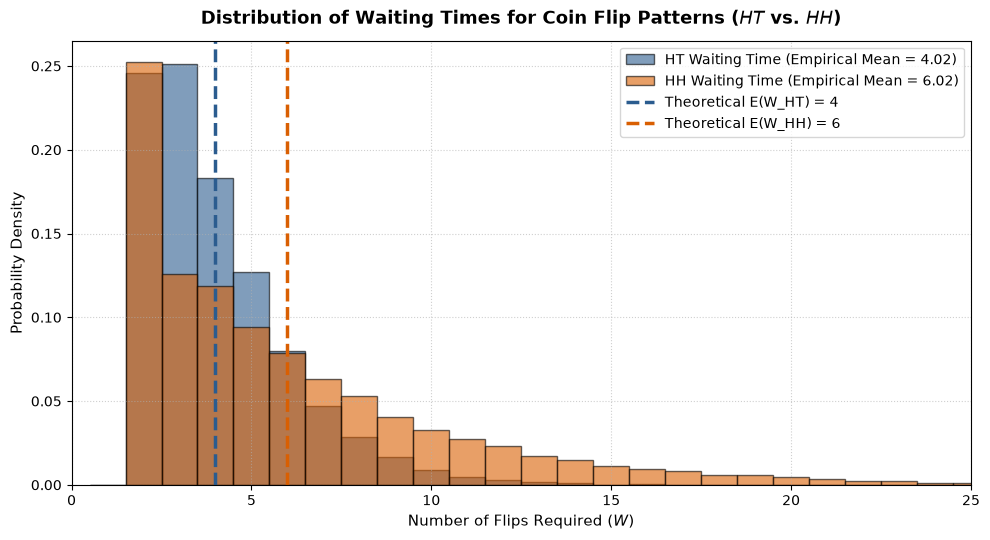

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

def simulate_waiting_time(pattern, n_simulations=10000):
    """Simulate average waiting time (number of coin flips) until pattern appears."""
    waiting_times = []
    for _ in range(n_simulations):
        flips = ""
        count = 0
        while pattern not in flips:
            flips += np.random.choice(['H', 'T'])
            count += 1
            # Keep only last len(pattern) characters to speed up string matching
            if len(flips) > len(pattern) + 2:
                flips = flips[-len(pattern):]
        waiting_times.append(count)
    return np.array(waiting_times)

n_sims = 15000
w_ht = simulate_waiting_time('HT', n_simulations=n_sims)
w_hh = simulate_waiting_time('HH', n_simulations=n_sims)

mean_ht_emp = np.mean(w_ht)
mean_hh_emp = np.mean(w_hh)

print(f"Empirical E(W_HT) over {n_sims} simulations: {mean_ht_emp:.3f} (Theoretical: 4.000)")
print(f"Empirical E(W_HH) over {n_sims} simulations: {mean_hh_emp:.3f} (Theoretical: 6.000)")

# Plotting the distributions and means
fig, ax = plt.subplots(figsize=(10, 5.5))

bins = np.arange(1, 30) - 0.5
ax.hist(w_ht, bins=bins, density=True, alpha=0.6, color='#2b5c8f', edgecolor='black', label=f'HT Waiting Time (Empirical Mean = {mean_ht_emp:.2f})')
ax.hist(w_hh, bins=bins, density=True, alpha=0.6, color='#d95f02', edgecolor='black', label=f'HH Waiting Time (Empirical Mean = {mean_hh_emp:.2f})')

ax.axvline(4.0, color='#2b5c8f', linestyle='--', linewidth=2.5, label='Theoretical E(W_HT) = 4')
ax.axvline(6.0, color='#d95f02', linestyle='--', linewidth=2.5, label='Theoretical E(W_HH) = 6')

ax.set_title('Distribution of Waiting Times for Coin Flip Patterns ($HT$ vs. $HH$)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Flips Required ($W$)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_xlim(0, 25)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

Empirical E(Y): 0.2517 (Theoretical E(Y) = E[X/2] = 0.2500)


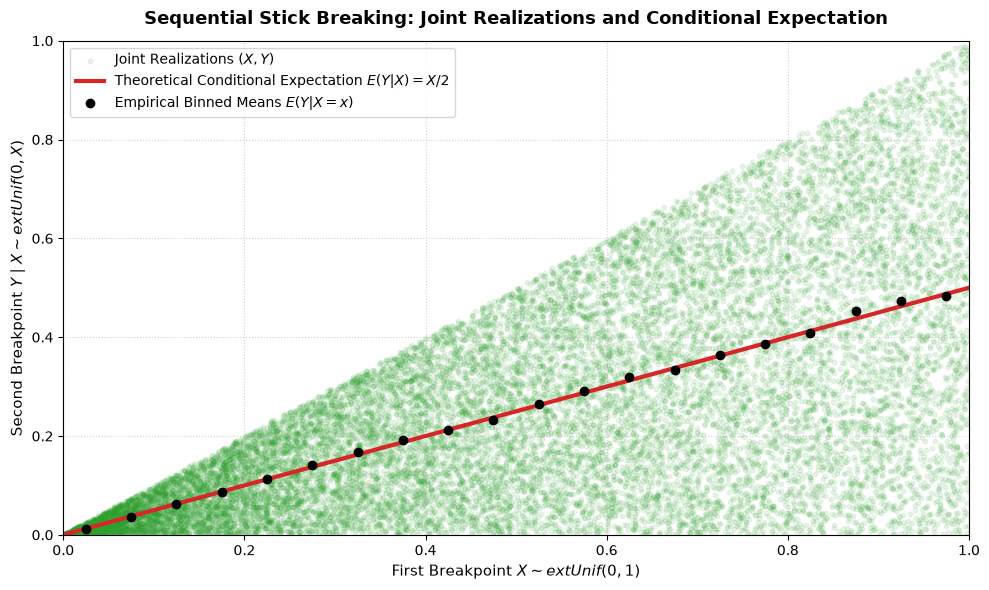

In [3]:
# Verification of Sequential Stick Breaking and Iterated Expectations
np.random.seed(101)

n_samples = 20000
# Step 1: X ~ Unif(0, 1)
X = np.random.uniform(0, 1, size=n_samples)
# Step 2: Y | X=x ~ Unif(0, x)
Y = np.random.uniform(0, X)

emp_mean_Y = np.mean(Y)
print(f"Empirical E(Y): {emp_mean_Y:.4f} (Theoretical E(Y) = E[X/2] = 0.2500)")

# Sort X for plotting theoretical conditional expectation curve
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
Y_cond_theo = X_sorted / 2.0

# Calculate empirical group means using binning along X
num_bins = 20
bin_edges = np.linspace(0, 1, num_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
emp_cond_means = [np.mean(Y[(X >= bin_edges[i]) & (X < bin_edges[i+1])]) for i in range(num_bins)]

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot of joint samples
ax.scatter(X, Y, alpha=0.1, s=10, color='#2ca02c', label='Joint Realizations $(X, Y)$')

# Theoretical conditional expectation line
ax.plot(X_sorted, Y_cond_theo, color='#d62728', linewidth=3, label='Theoretical Conditional Expectation $E(Y | X) = X/2$')

# Empirical conditional means
ax.plot(bin_centers, emp_cond_means, 'o', color='black', markersize=6, label='Empirical Binned Means $E(Y | X=x)$')

ax.set_title('Sequential Stick Breaking: Joint Realizations and Conditional Expectation', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('First Breakpoint $X \sim \text{Unif}(0, 1)$', fontsize=11)
ax.set_ylabel('Second Breakpoint $Y \mid X \sim \text{Unif}(0, X)$', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

Empirical Covariance Cov(Y - E(Y|X), h(X)): -0.044409 (Theoretical: 0.000000)
Total Variance Var(Y):                   4.5765
Explained Variance Var[E(Y|X)]:          3.9743
Unexplained Variance E[Var(Y|X)]:        0.6251
Sum of Explained + Unexplained:          4.5994 (Matches Var(Y))


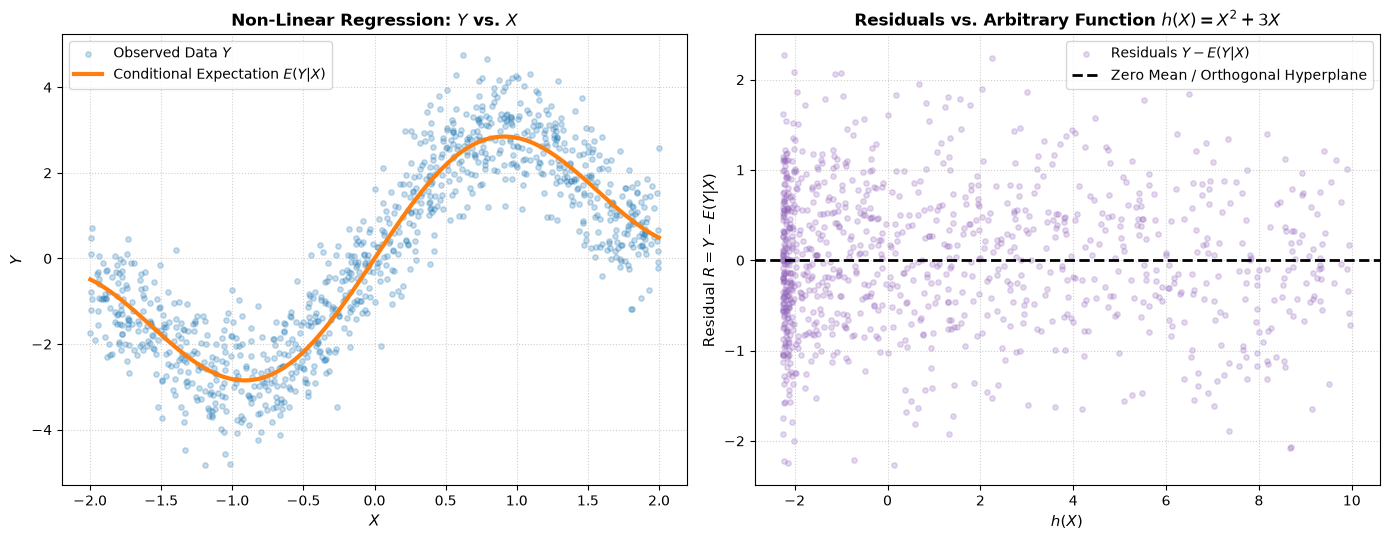

In [4]:
# Verification of Residual Orthogonality and Variance Decomposition
np.random.seed(2026)

n_pts = 10000
# Generate non-linear relationship: Y = 2*sin(2*X) + X + epsilon
X_data = np.random.uniform(-2, 2, size=n_pts)
true_cond_exp = 2 * np.sin(2 * X_data) + X_data
noise = np.random.normal(0, 0.8, size=n_pts)
Y_data = true_cond_exp + noise

# Residual R = Y - E(Y|X) = noise
residuals = Y_data - true_cond_exp

# Check orthogonality with any function h(X), e.g., h(X) = X^2 + 3*X
h_X = X_data**2 + 3 * X_data
cov_residual_hX = np.cov(residuals, h_X)[0, 1]

# Check Law of Total Variance: Var(Y) = E[Var(Y|X)] + Var[E(Y|X)]
var_Y_total = np.var(Y_data)
var_explained = np.var(true_cond_exp)       # Var[E(Y|X)]
var_unexplained = np.var(residuals)         # E[Var(Y|X)] (since Var(Y|X) is constant noise variance)

print(f"Empirical Covariance Cov(Y - E(Y|X), h(X)): {cov_residual_hX:.6f} (Theoretical: 0.000000)")
print(f"Total Variance Var(Y):                   {var_Y_total:.4f}")
print(f"Explained Variance Var[E(Y|X)]:          {var_explained:.4f}")
print(f"Unexplained Variance E[Var(Y|X)]:        {var_unexplained:.4f}")
print(f"Sum of Explained + Unexplained:          {(var_explained + var_unexplained):.4f} (Matches Var(Y))")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: Prediction and Residuals
ax1.scatter(X_data[:1000], Y_data[:1000], alpha=0.25, color='#1f77b4', s=15, label='Observed Data $Y$')
sort_idx = np.argsort(X_data[:1000])
ax1.plot(X_data[:1000][sort_idx], true_cond_exp[:1000][sort_idx], color='#ff7f0e', linewidth=3, label='Conditional Expectation $E(Y|X)$')
ax1.set_title('Non-Linear Regression: $Y$ vs. $X$', fontsize=12, fontweight='bold')
ax1.set_xlabel('$X$', fontsize=11)
ax1.set_ylabel('$Y$', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left')

# Plot 2: Residuals vs h(X) showing zero correlation
ax2.scatter(h_X[:1000], residuals[:1000], alpha=0.25, color='#9467bd', s=15, label='Residuals $Y - E(Y|X)$')
ax2.axhline(0, color='black', linestyle='--', linewidth=2, label='Zero Mean / Orthogonal Hyperplane')
ax2.set_title('Residuals vs. Arbitrary Function $h(X) = X^2 + 3X$', fontsize=12, fontweight='bold')
ax2.set_xlabel('$h(X)$', fontsize=11)
ax2.set_ylabel('Residual $R = Y - E(Y|X)$', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

> **References & Acknowledgments:**
> Topics covered align with foundational probability theory and personal handwritten lecture notes on conditional expectation, iterated expectations, and variance decomposition.